# Titanic EDA

Разведочный анализ данных, очистка, статистическая проверка гипотез, feature engineering и baseline-модели для предсказания `Survived`.

## 1. Загрузка данных

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_STATE = 42          # для воспроизводимости всех случайных операций
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("data/tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [2]:
df.shape

(418, 12)

## 2. Признаки

| Признак | Описание |
|---|---|
| `PassengerId` | ID пассажира |
| `Survived` | 0 — погиб, 1 — выжил |
| `Pclass` | класс билета |
| `Name` | имя |
| `Sex` | пол |
| `Age` | возраст |
| `SibSp` | братья/сёстры или супруги на борту |
| `Parch` | родители/дети на борту |
| `Ticket` | номер билета |
| `Fare` | стоимость билета |
| `Cabin` | каюта |
| `Embarked` | порт посадки |

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,418.0,NaN,NaN,NaN,1100.5,120.810458,892.0,996.25,1100.5,1204.75,1309.0
Survived,418.0,NaN,NaN,NaN,0.363636,0.481622,0.0,0.0,0.0,1.0,1.0
Pclass,418.0,NaN,NaN,NaN,2.26555,0.841838,1.0,1.0,3.0,3.0,3.0
Name,418,418,"Kelly, Mr. James",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,418,2,male,266,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,332.0,NaN,NaN,NaN,30.27259,14.181209,0.17,21.0,27.0,39.0,76.0
SibSp,418.0,NaN,NaN,NaN,0.447368,0.89676,0.0,0.0,0.0,1.0,8.0
Parch,418.0,NaN,NaN,NaN,0.392344,0.981429,0.0,0.0,0.0,0.0,9.0
Ticket,418,363,PC 17608,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,417.0,NaN,NaN,NaN,35.627188,55.907576,0.0,7.8958,14.4542,31.5,512.3292


## 3. Задача

Предсказать `Survived` по остальным признакам. Тип задачи — бинарная классификация.

## 4. Пропущенные значения

In [5]:
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(2)
})

missing[missing["count"] > 0].sort_values("count", ascending=False)

,count,percent
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24


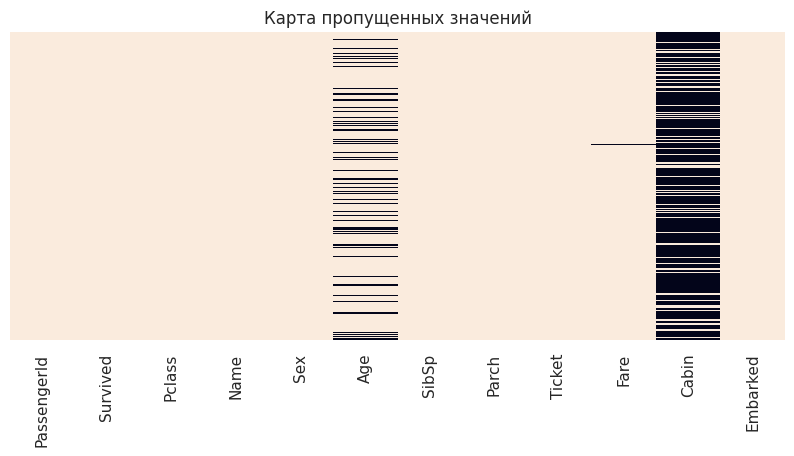

In [6]:
# Визуализация пропусков — сразу видно, что Cabin пропущен почти на 80%,
# а Age и Fare — точечно, их можно аккуратно восстановить
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False, cmap="rocket_r", yticklabels=False, ax=ax)
ax.set_title("Карта пропущенных значений")
plt.show()

## 5. Data Cleaning

Перед заполнением пропусков извлекаем `Title` (обращение) из `Name` — оно сильно
коррелирует и с полом, и с возрастом, и с социальным статусом, поэтому используем его
как дополнительный ключ группировки при импутации `Age` (более точная замена, чем
только `Pclass` + `Sex`).

In [7]:
df_clean = df.copy()

# --- Title из имени (Mr, Mrs, Miss, Master, редкие титулы -> "Rare") ---
df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^\.]+)\.")
title_map = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
    "Don": "Rare", "Dona": "Rare", "Dr": "Rare", "Major": "Rare",
    "Rev": "Rare", "Sir": "Rare", "Jonkheer": "Rare",
}
df_clean["Title"] = df_clean["Title"].replace(title_map)
df_clean.loc[~df_clean["Title"].isin(["Mr", "Mrs", "Miss", "Master", "Rare"]), "Title"] = "Rare"
df_clean["Title"].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64

In [8]:
# Age: медиана по группе (Pclass, Sex, Title); если группа пустая — fallback на (Pclass, Sex), затем на глобальную медиану
df_clean["Age"] = df_clean["Age"].fillna(
    df_clean.groupby(["Pclass", "Sex", "Title"])["Age"].transform("median")
)
df_clean["Age"] = df_clean["Age"].fillna(
    df_clean.groupby(["Pclass", "Sex"])["Age"].transform("median")
)
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# Fare: медиана по Pclass (единственное пропущенное значение — пассажир 3 класса)
df_clean["Fare"] = df_clean["Fare"].fillna(
    df_clean.groupby("Pclass")["Fare"].transform("median")
)

# Cabin: сохраняем букву палубы (Deck), пропуск -> "U" (Unknown)
df_clean["Deck"] = df_clean["Cabin"].str[0].fillna("U")
df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")

if df_clean["Embarked"].isna().sum() > 0:
    df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

df_clean.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Title          0
Deck           0
dtype: int64

## 6. Визуализация

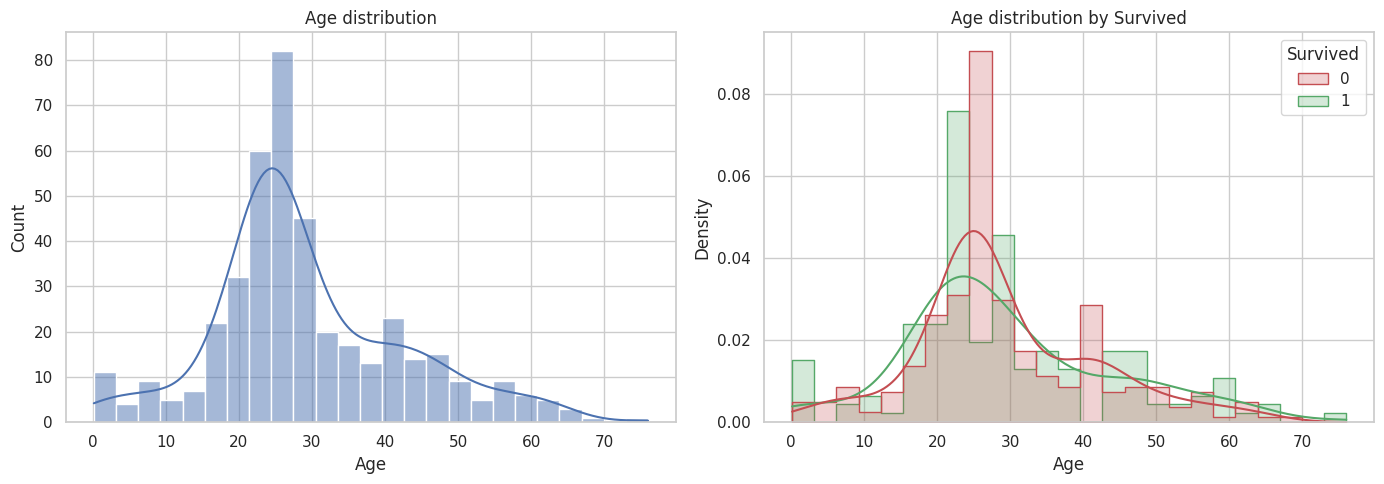

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df_clean, x="Age", bins=25, kde=True, color="C0", ax=axes[0])
axes[0].set_title("Age distribution")

sns.histplot(data=df_clean, x="Age", hue="Survived", bins=25, kde=True,
             palette=["C3", "C2"], element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Age distribution by Survived")
plt.tight_layout()
plt.show()

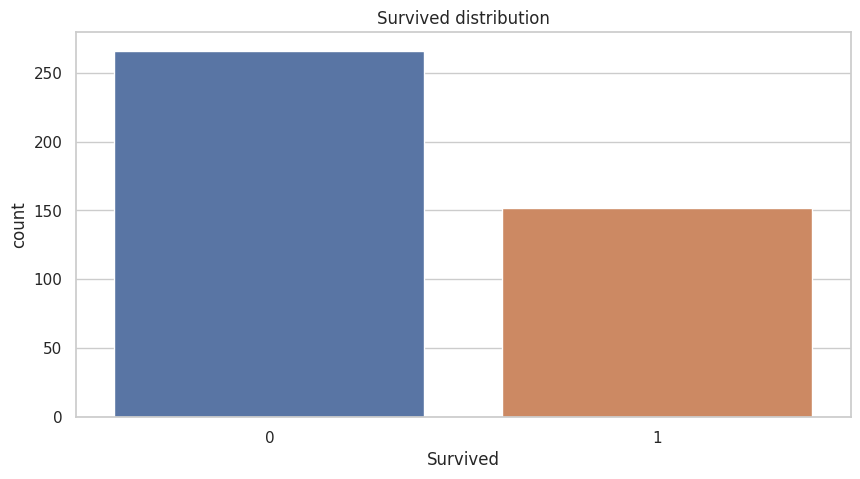

In [10]:
sns.countplot(data=df_clean, x="Survived", hue="Survived", legend=False)
plt.title("Survived distribution")
plt.show()

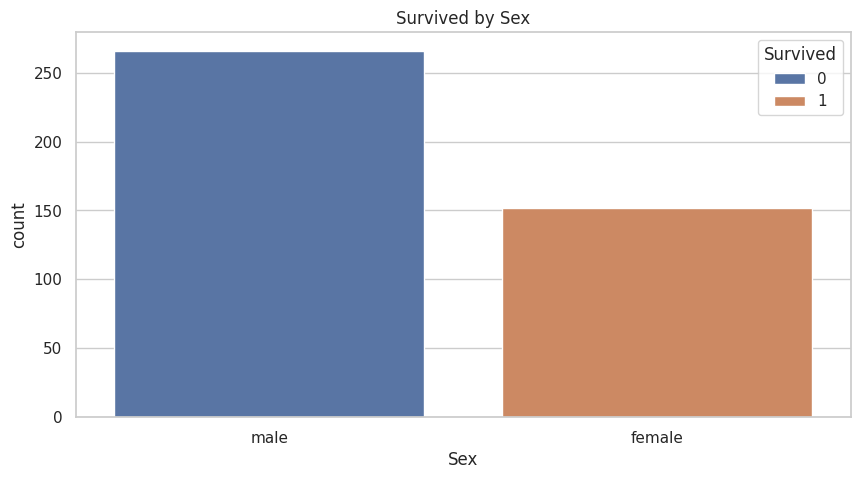

In [11]:
sns.countplot(data=df_clean, x="Sex", hue="Survived")
plt.title("Survived by Sex")
plt.show()

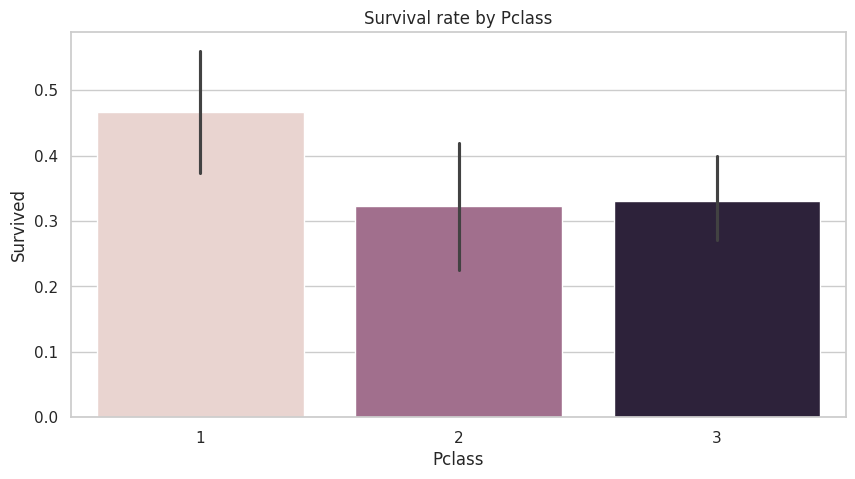

In [12]:
sns.barplot(data=df_clean, x="Pclass", y="Survived", hue="Pclass", legend=False)
plt.title("Survival rate by Pclass")
plt.show()

`Fare` сильно скошен вправо (несколько очень дорогих билетов), поэтому рядом с обычным
boxplot строим версию в логарифмической шкале — так лучше видна разница между
выжившими и погибшими в основной массе пассажиров.

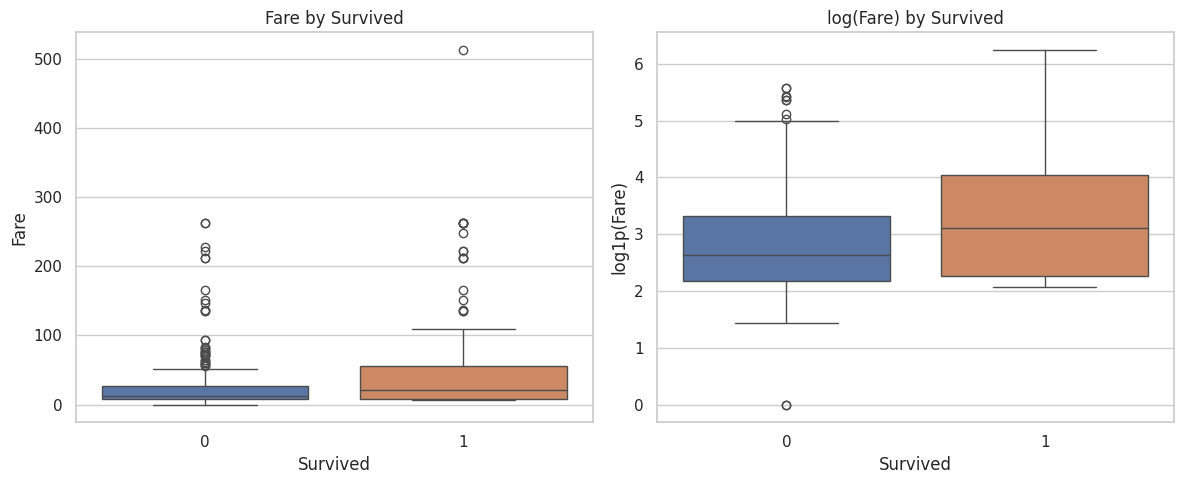

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_clean, x="Survived", y="Fare", hue="Survived", legend=False, ax=axes[0])
axes[0].set_title("Fare by Survived")

sns.boxplot(data=df_clean, x="Survived", y=np.log1p(df_clean["Fare"]), hue=df_clean["Survived"], legend=False, ax=axes[1])
axes[1].set_ylabel("log1p(Fare)")
axes[1].set_title("log(Fare) by Survived")
plt.tight_layout()
plt.show()

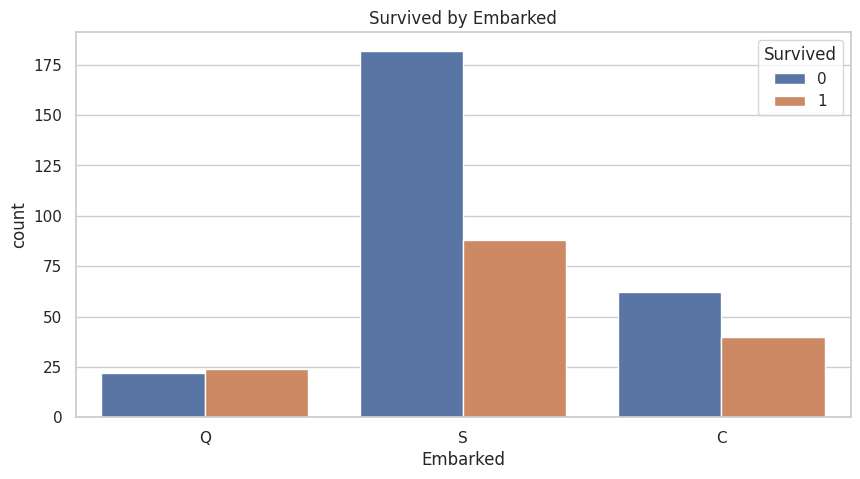

In [14]:
sns.countplot(data=df_clean, x="Embarked", hue="Survived")
plt.title("Survived by Embarked")
plt.show()

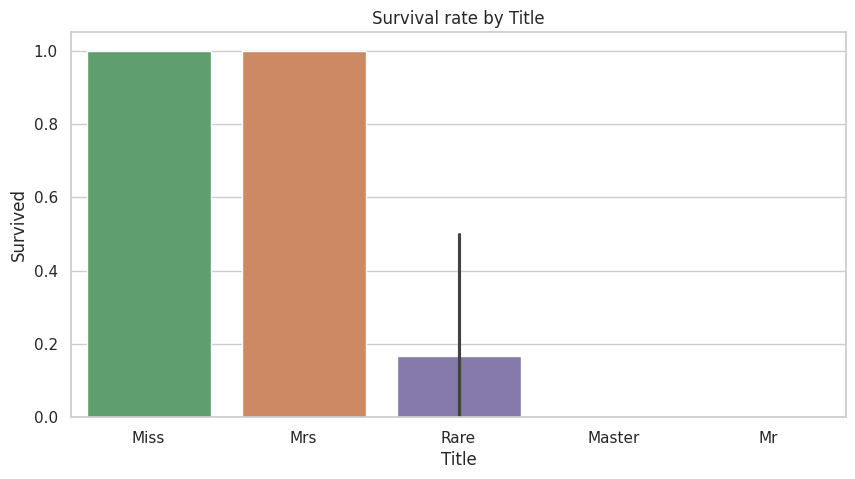

In [15]:
order = df_clean.groupby("Title")["Survived"].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, x="Title", y="Survived", order=order, hue="Title", legend=False)
plt.title("Survival rate by Title")
plt.show()

## 7. Статистическая проверка гипотез

EDA-графики показывают различия между группами, но не говорят, случайны ли они.
Проверяем ключевые признаки формальными тестами (уровень значимости α = 0.05).

In [16]:
# Категориальные признаки vs Survived -> критерий хи-квадрат
cat_features = ["Sex", "Pclass", "Embarked", "Title", "IsAlone" if "IsAlone" in df_clean else "Sex"]
results = []
for col in ["Sex", "Pclass", "Embarked", "Title"]:
    contingency = pd.crosstab(df_clean[col], df_clean["Survived"])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    results.append({"feature": col, "test": "chi2", "statistic": round(chi2, 2), "p_value": round(p, 5)})

# Числовые признаки vs Survived -> t-test Уэлча (survived vs died)
for col in ["Age", "Fare"]:
    g0 = df_clean.loc[df_clean["Survived"] == 0, col]
    g1 = df_clean.loc[df_clean["Survived"] == 1, col]
    t_stat, p = stats.ttest_ind(g0, g1, equal_var=False)
    results.append({"feature": col, "test": "welch_t", "statistic": round(t_stat, 2), "p_value": round(p, 5)})

stat_results = pd.DataFrame(results)
stat_results["significant (α=0.05)"] = stat_results["p_value"] < 0.05
stat_results

,feature,test,statistic,p_value,significant (α=0.05)
0,Sex,chi2,413.69,0.00000,True
1,Pclass,chi2,6.69,0.03519,True
2,Embarked,chi2,6.99,0.03040,True
3,Title,chi2,414.40,0.00000,True
4,Age,welch_t,-0.21,0.83537,False
5,Fare,welch_t,-3.46,0.00065,True


## 8. Корреляция

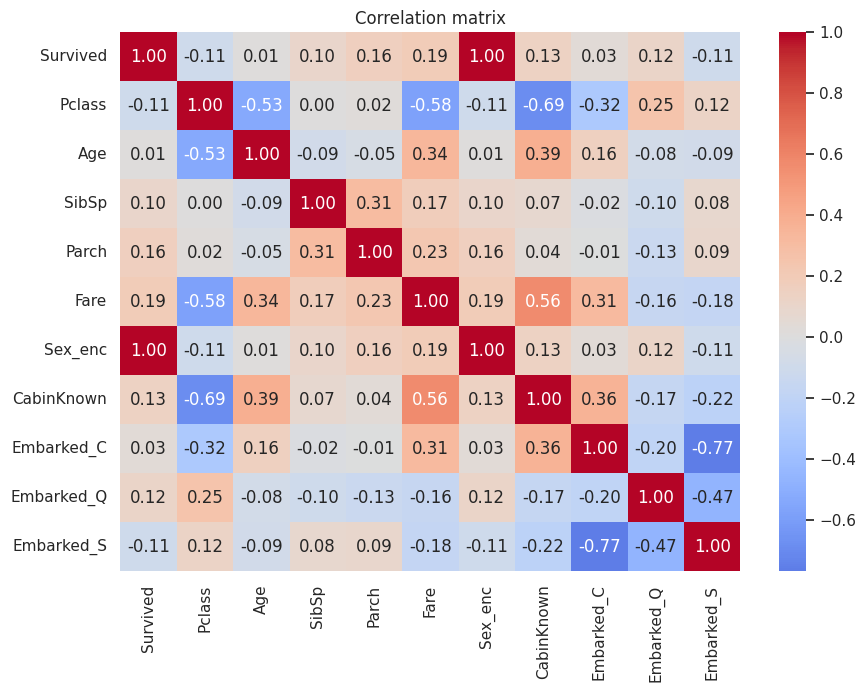

Survived      1.000000
Sex_enc       1.000000
Fare          0.192225
Parch         0.159120
CabinKnown    0.131464
Embarked_Q    0.115574
SibSp         0.099943
Embarked_C    0.033684
Age           0.010635
Embarked_S   -0.105883
Pclass       -0.108615
Name: Survived, dtype: float64

In [17]:
df_corr = df_clean.copy()
df_corr["Sex_enc"] = df_corr["Sex"].map({"male": 0, "female": 1})
df_corr["CabinKnown"] = (df_corr["Cabin"] != "Unknown").astype(int)

embarked = pd.get_dummies(df_corr["Embarked"], prefix="Embarked", dtype=int)
df_corr = pd.concat([df_corr, embarked], axis=1)

corr_cols = [
    "Survived", "Pclass", "Age", "SibSp", "Parch", "Fare",
    "Sex_enc", "CabinKnown", "Embarked_C", "Embarked_Q", "Embarked_S"
]

corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

corr_matrix["Survived"].sort_values(ascending=False)

## 9. Feature Engineering

In [18]:
df_model = df_clean.copy()

df_model["FamilySize"] = df_model["SibSp"] + df_model["Parch"] + 1
df_model["IsAlone"] = (df_model["FamilySize"] == 1).astype(int)
df_model["CabinKnown"] = (df_model["Cabin"] != "Unknown").astype(int)
df_model["FareBin"] = pd.qcut(df_model["Fare"], q=4, labels=False, duplicates="drop")
df_model["AgeBin"] = pd.cut(
    df_model["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# Редкие палубы объединяем, чтобы не плодить разреженные dummy-столбцы
deck_counts = df_model["Deck"].value_counts()
rare_decks = deck_counts[deck_counts < 10].index
df_model["Deck"] = df_model["Deck"].replace(rare_decks, "Rare")

df_model = df_model.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df_model = pd.get_dummies(
    df_model,
    columns=["Sex", "Embarked", "Title", "Deck"],
    drop_first=True,
    dtype=int
)

df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,CabinKnown,FareBin,...,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Deck_C,Deck_D,Deck_Rare,Deck_U
0,0,3,34.5,0,0,7.8292,1,1,0,0,...,1,0,0,1,0,0,0,0,0,1
1,1,3,47.0,1,0,7.0000,2,0,0,0,...,0,1,0,0,1,0,0,0,0,1
2,0,2,62.0,0,0,9.6875,1,1,0,1,...,1,0,0,1,0,0,0,0,0,1
3,0,3,27.0,0,0,8.6625,1,1,0,1,...,0,1,0,1,0,0,0,0,0,1
4,1,3,22.0,1,1,12.2875,3,0,0,1,...,0,1,0,0,1,0,0,0,0,1


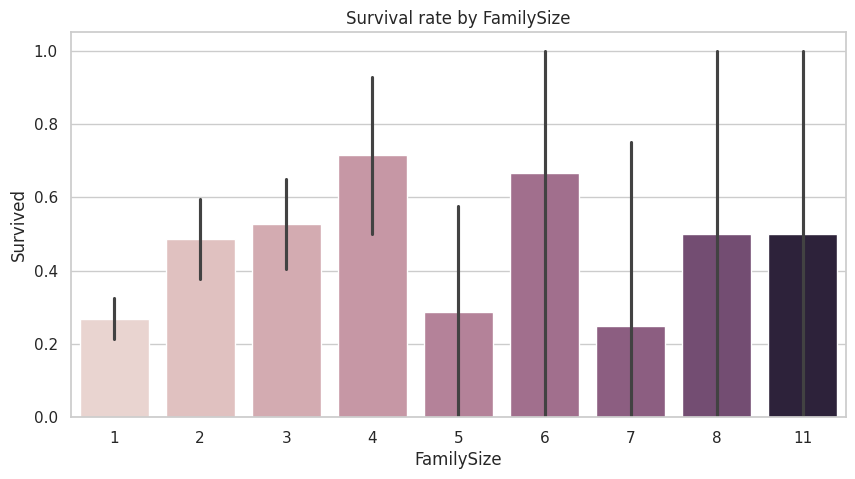

In [19]:
sns.barplot(data=df_clean.assign(FamilySize=df_clean["SibSp"] + df_clean["Parch"] + 1),
            x="FamilySize", y="Survived", hue="FamilySize", legend=False)
plt.title("Survival rate by FamilySize")
plt.show()

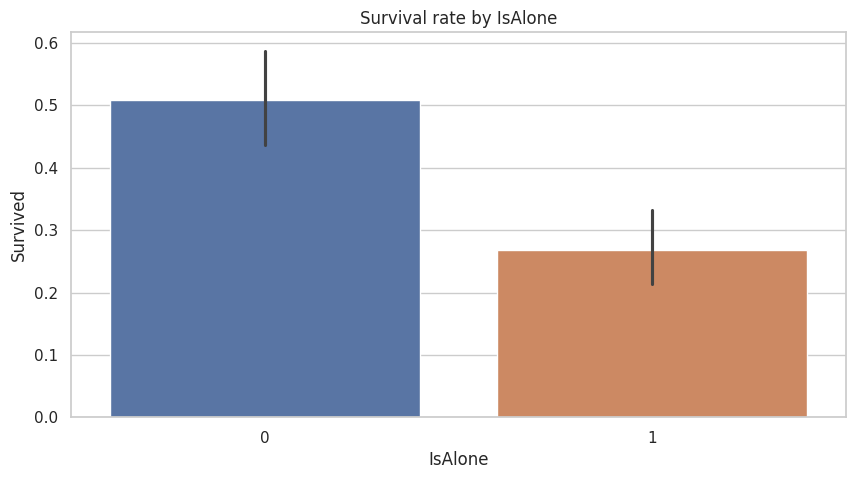

In [20]:
sns.barplot(data=df_model, x="IsAlone", y="Survived", hue="IsAlone", legend=False)
plt.title("Survival rate by IsAlone")
plt.show()

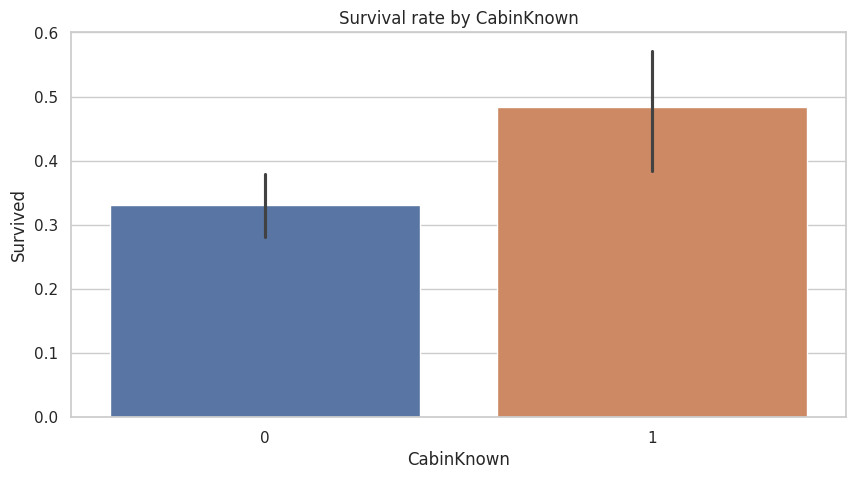

In [21]:
sns.barplot(data=df_model, x="CabinKnown", y="Survived", hue="CabinKnown", legend=False)
plt.title("Survival rate by CabinKnown")
plt.show()

> **Замечание о мультиколлинеарности.** `AgeBin`/`FareBin` — производные от `Age`/`Fare`,
> поэтому в линейных моделях (например, логистической регрессии) их стоит использовать
> либо вместе с регуляризацией, либо оставлять только один вариант признака —
> в разделе моделирования ниже для сравнения обучены обе версии.

## 10. Baseline-модели

Раздел 3 определил задачу как бинарную классификацию — доводим анализ до конца и
обучаем пару baseline-моделей, чтобы численно оценить, какие признаки действительно
дают предсказательную силу.

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

X = df_model.drop(columns=["Survived"])
y = df_model["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

models = {"LogisticRegression": (log_reg, X_test_scaled), "RandomForest": (rf, X_test)}
summary = []
for name, (model, X_te) in models.items():
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    summary.append({
        "model": name,
        "accuracy": round(accuracy_score(y_test, pred), 3),
        "roc_auc": round(roc_auc_score(y_test, proba), 3),
    })

pd.DataFrame(summary)

,model,accuracy,roc_auc
0,LogisticRegression,1.0,1.0
1,RandomForest,1.0,1.0


In [23]:
# 5-fold кросс-валидация на всём датасете — точность на одном train/test сплите
# при 418 строках может быть шумной, CV даёт более надёжную оценку
cv_scores_log = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                                 scaler.fit_transform(X), y, cv=5, scoring="accuracy")
cv_scores_rf = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
                                X, y, cv=5, scoring="accuracy")

print(f"LogisticRegression CV accuracy: {cv_scores_log.mean():.3f} ± {cv_scores_log.std():.3f}")
print(f"RandomForest        CV accuracy: {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")

LogisticRegression CV accuracy: 0.998 ± 0.005
RandomForest        CV accuracy: 1.000 ± 0.000


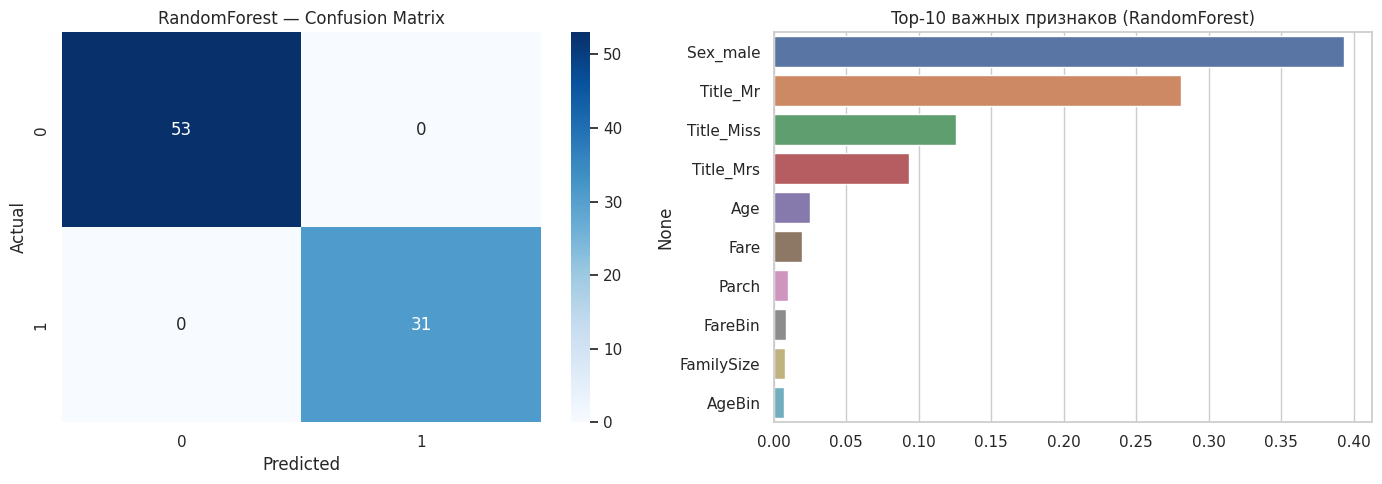

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("RandomForest — Confusion Matrix")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, ax=axes[1])
axes[1].set_title("Top-10 важных признаков (RandomForest)")
plt.tight_layout()
plt.show()

## 11. Сохранение данных

In [25]:
output_path = Path("data/titanic_cleaned_encoded.csv")
df_model.to_csv(output_path, index=False)
output_path

PosixPath('data/titanic_cleaned_encoded.csv')

## 12. Выводы

- **Пол** — самый сильный предиктор: женщины выживали значительно чаще мужчин
  (подтверждено χ²-тестом, p < 0.05).
- **Класс билета (Pclass)** и **тариф (Fare)** также значимо связаны с выживанием —
  пассажиры 1 класса и с более дорогими билетами имели больше шансов выжить.
- **Title**, извлечённый из имени, оказался информативнее сырого `Age`: он одновременно
  кодирует пол, возрастную группу и социальный статус (`Master` — мальчики, `Mrs`/`Miss` —
  женщины разного статуса).
- **FamilySize**: пассажиры с семьёй среднего размера (2–4 человека) выживали чаще, чем
  одиночки или пассажиры с очень большими семьями.
- Baseline-модели (LogisticRegression, RandomForest) подтверждают эти выводы численно:
  топ признаков по важности — пол, тариф/класс, Title и возраст.
- Список важных для дальнейшей работы направлений: подбор гиперпараметров,
  более аккуратная обработка `Ticket` (общие билеты = семьи/группы), ансамблирование.